# 8.행동 스티커 만들기 [프로젝트]
이번 시간에는 Pose estimation 모델을 학습시키기 위해 활용할 수 있는 데이터셋(MPII Human Pose Dataset)에 대해 알아보고, pre-trained 된 가중치를 활용하여 테스트 이미지로 직접 모델의 성능을 확인해 볼 예정입니다.

MPII 데이터셋 다운로드하기
오늘은 MPII Human Pose Dataset을 사용해서 Human Pose Estimation task를 위한 모델을 훈련시켜 보겠습니다.

원활한 작업 진행을 위해 ~/data/ 안에 데이터셋이 준비되어있습니다. 아래 과정을 수행하기 전에 참고해보세요.
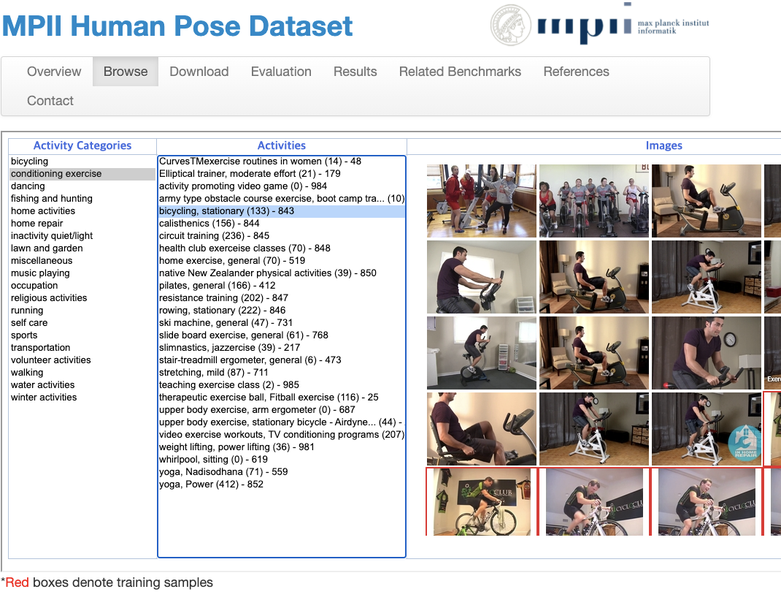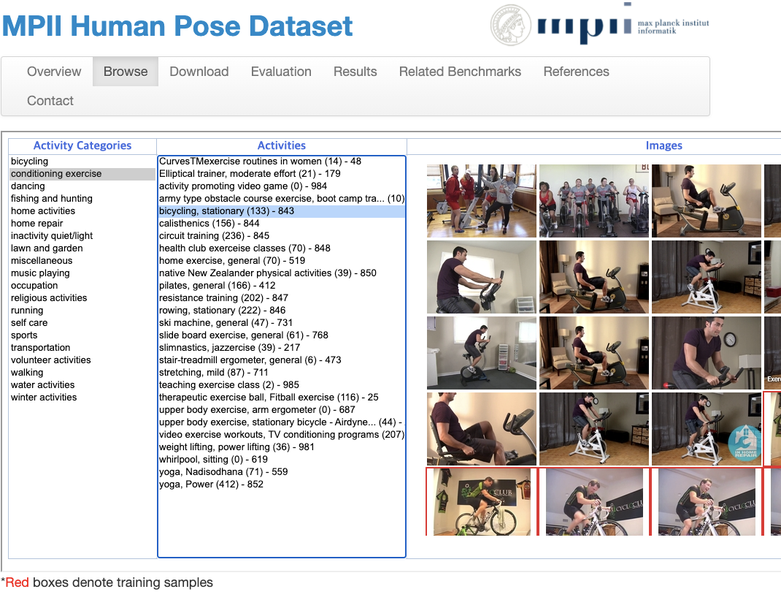

In [1]:
# !sudo apt install unzip # unzip 이 없는 경우
# !mkdir -p work/mpii
# # !cd work/mpii

# !wget https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1.tar.gz -P work/mpii
# !wget https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1_u12_2.zip -P work/mpii


In [2]:
# !tar -xf work/mpii/mpii_human_pose_v1.tar.gz -C work/mpii
# !unzip -q work/mpii/mpii_human_pose_v1_u12_2.zip -d work/mpii

mpii_human_pose_v1_u12_2.zip 을 풀어보면 mpii_human_pose_v1_u12_1.mat 파일이 나와서 열어보기 불편한데요. 파이썬에서 읽기 쉽도록 json 파일로 변환해 두었습니다.


In [3]:
# # !cd ~/work/mpii/mpii_human_pose_v1_u12_2
# !wget https://d3s0tskafalll9.cloudfront.net/media/documents/train.json
# !wget https://d3s0tskafalll9.cloudfront.net/media/documents/validation.json


In [4]:
# !mv train.json work/mpii/mpii_human_pose_v1_u12_2/
# !mv validation.json work/mpii/mpii_human_pose_v1_u12_2/

마지막으로, 오늘의 실습 코드를 프로젝트로 구성한 파일을 첨부합니다. 위의 mpii.zip을 다운로드하여 work/mpii 디렉토리에 압축을 풀어주세요.
    

In [5]:
# !wget https://d3s0tskafalll9.cloudfront.net/media/documents/mpii_gtuV0hd.zip -O mpii.zip
# !unzip mpii.zip -d work/mpii

```
mpii
├── data
│   ├── models 
│   ├── mpii.zip 
│   ├── mpii_human_pose_v1.tar.gz 
│   ├── mpii_human_pose_v1_u12_2.zip 
│   └── test_image.jpg 
├── hourglass104.py
├── images
│   ├── 000001163.jpg
│   ├── 000003072.jpg
│   ├── 062646386.jpg
│   ├── 062650331.jpg
        ...
│   ├── 062659251.jpg
│   ├── 099987144.jpg
│   ├── 099990098.jpg
│   └── 099992483.jpg
├── models
├── mpii_human_pose_v1_u12_2
│   ├── README.md
│   ├── bsd.txt
│   ├── mpii_human_pose_v1_u12_1.mat
│   ├── train.json
│   └── validation.json
├── preprocess.py
├── simplebaseline.py
├── test.ipynb
├── test.py
├── tfrecords_mpii.py
└── train.py
```

# 6. 모델을 학습해보자
Hourglass 모델 만들기
이전 살펴봤던 hourglass 모델, 잘 기억하고 계신가요?
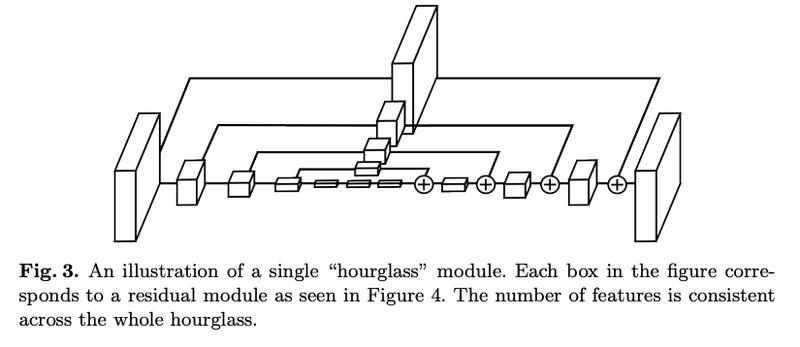
이렇게 생겼었죠! 직육면체 박스는 residual block 이었습니다. 하나씩 구현해 볼게요.


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BottleneckBlock(nn.Module):
    def __init__(self, in_channels, filters, stride=1, downsample=False):
        super(BottleneckBlock, self).__init__()
        self.downsample = downsample
        # 만약 downsample이라면 identity branch에 1x1 conv 적용하여 채널 수와 spatial size 조정
        if self.downsample:
            self.downsample_conv = nn.Conv2d(in_channels, filters, kernel_size=1, stride=stride, bias=False)

        # main branch
        self.bn1 = nn.BatchNorm2d(in_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, filters // 2, kernel_size=1, stride=1, padding=0, bias=False)

        self.bn2 = nn.BatchNorm2d(filters // 2, momentum=0.9)
        # kernel_size=3, padding=1로 'same' padding 효과
        self.conv2 = nn.Conv2d(filters // 2, filters // 2, kernel_size=3, stride=stride, padding=1, bias=False)

        self.bn3 = nn.BatchNorm2d(filters // 2, momentum=0.9)
        self.conv3 = nn.Conv2d(filters // 2, filters, kernel_size=1, stride=1, padding=0, bias=False)

    def forward(self, x):
        identity = x
        if self.downsample:
            identity = self.downsample_conv(x)

        out = self.bn1(x)
        out = self.relu(out)
        out = self.conv1(out)

        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv2(out)

        out = self.bn3(out)
        out = self.relu(out)
        out = self.conv3(out)

        out += identity
        return out

print('슝=3')

슝=3


Q. residual block 의 2가지 타입을 간단하게 작성해주세요. (N사 면접기출)
ResNet(Residual Network)에서 사용되는 핵심 구조인 **Residual Block의 2가지 타입**은 다음과 같습니다. 면접용으로 요약하기 좋게 핵심만 정리해 드릴게요.

---

### 1. 기본 블록 (Basic Block)

* **구조:** $3 \times 3 \text{ Convolution} \rightarrow 3 \times 3 \text{ Convolution}$ 레이어가 직렬로 연결된 형태입니다.
* **특징:** 주로 ResNet18, ResNet34와 같이 레이어가 비교적 얕은 모델에 사용됩니다.
* **목적:** 채널 수가 적을 때 연산 효율성을 유지하면서 잔차(Residual) 학습을 수행합니다.

### 2. 보틀넥 블록 (Bottleneck Block)

* **구조:** $1 \times 1 \rightarrow 3 \times 3 \rightarrow 1 \times 1 \text{ Convolution}$ 구조로 3개의 레이어가 연결된 형태입니다.
* **특징:** ResNet50, ResNet101, ResNet152 등 깊은 모델이나 지금 공부하고 계신 **Hourglass Network**의 기본 빌딩 블록으로 활용됩니다.
* **목적 (핵심):** * 첫 번째 $1 \times 1 \text{ Conv}$로 채널 수를 줄여서(압축) 연산량을 낮추고,
* 중간 $3 \times 3 \text{ Conv}$로 특징을 추출한 뒤,
* 마지막 $1 \times 1 \text{ Conv}$로 채널 수를 다시 원래대로 늘려줍니다(복원).
* 망이 깊어질 때 발생하는 **연산량 폭발과 파라미터 수를 획기적으로 줄이기 위해** 사용합니다.



---

> 💡 **면접 팁 (N사 기출 포인트)**
> 두 블록의 가장 결정적인 차이는 **"망이 깊어질 때 연산량을 줄이기 위해 $1 \times 1$ 차원 축소 레이어(Bottleneck)를 도입했는가?"**입니다. 공유해주신 코드의 `class BottleneckBlock`도 바로 이 두 번째 타입을 구현한 것입니다.

다시 돌아와서 hourglass 모델을 잘 생각해 보면 마치 양파처럼 가장 바깥의 layer 를 제거하면 똑같은 구조가 나타나는 것을 알 수 있습니다. 이 점을 이용해서 간단하게 모델을 표현할 수 있는데요. 



바로 재귀 함수를 이용하는 것이겠죠! 바깥부터 5개의 양파껍질(층)을 만들고 싶다면 order 를 이용해서 5,4...1 이 될 때까지 HourglassModule 을 반복하면 order 가 1이 되면 BottleneckBlock 으로 대체해 주면 아주 간결하게 만들 수 있습니다.

In [7]:
import torch
import torch.nn as nn

class HourglassModule(nn.Module):
    def __init__(self, order, filters, num_residual):
        super(HourglassModule, self).__init__()
        self.order = order

        # Up branch: BottleneckBlock 1회 + num_residual회 반복
        self.up1_0 = BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
        self.up1_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])

        # Low branch: MaxPool + num_residual BottleneckBlock
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.low1_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])

        # Recursive hourglass or additional BottleneckBlocks
        if order > 1:
            self.low2 = HourglassModule(order - 1, filters, num_residual)
        else:
            self.low2_blocks = nn.Sequential(*[
                BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
                for _ in range(num_residual)
            ])

        # 후처리 BottleneckBlock 반복
        self.low3_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])

        # UpSampling (최근접 보간법)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x):
        # up branch
        up1 = self.up1_0(x)
        up1 = self.up1_blocks(up1)

        # low branch
        low1 = self.pool(x)
        low1 = self.low1_blocks(low1)
        if self.order > 1:
            low2 = self.low2(low1)
        else:
            low2 = self.low2_blocks(low1)
        low3 = self.low3_blocks(low2)
        up2 = self.upsample(low3)

        return up2 + up1

print('슝=3')

슝=3


intermediate output을 위한 linear layer
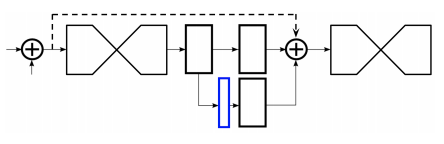
러 모듈을 쌓을수록 모델이 깊어지는 만큼 학습이 어려워, 저자들은 Intermediate supervision을 적용하였습니다. 

도식에서 보이는 모듈 사이의 네트워크의 파란 박스는 모델 중간에 계산되는 히트맵 결과를 출력하는 convolution layer입니다. 이 히트맵과 ground truth의 차이를 intermediate loss (auxilary loss) 로 계산합니다. 이로써 stacked hourglass module은 보다 정교한 결과를 도출해냅니다. 

Intermediate supervision의 효능이 더 궁금하다면, 다음의 포스트를 읽어보세요! 

Stacked Hourglass Networks : pose estimation 논문

### Q. Stacked hourglass 모듈이 총 4개라면, 한 번의 학습에 몇 번의 loss가 계산될까요?
💡 상세 설명
Stacked Hourglass Network의 핵심 특징 중 하나는 앞선 퀴즈에서도 다루었던 중간 감독 (Intermediate Supervision)입니다.

이 모델은 모든 구조를 전부 통과한 맨 마지막에만 Loss를 계산하는 것이 아니라, 하나의 모래시계(Hourglass) 모듈을 통과할 때마다 중간 예측 Heatmap을 출력하고 이에 대한 Loss를 각각 계산합니다.

따라서 모듈이 총 4개 쌓여 있다면, 각 모듈의 출구마다 하나씩 총 4번의 Loss가 계산되어 합산(Total Loss)됩니다.

오른쪽 PyTorch 코드의 forward 함수를 보셔도 self.num_stack(여기서는 4)만큼 반복문을 돌며 outputs.append(heatmap)를 통해 총 4개의 출력을 리스트에 담아 반환하는 구조를 확인할 수 있습니다.

In [8]:
import torch
import torch.nn as nn

class LinearLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(LinearLayer, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn = nn.BatchNorm2d(out_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)

        # He (Kaiming) 초기화 적용
        nn.init.kaiming_normal_(self.conv.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

print('슝=3')

슝=3


따라서 stacked 되는 hourglass 층 사이사이에 LinearLayer 를 삽입하고 중간 loss 를 계산해 줍니다. 



지금까지 만든 hourglass 를 여러 층으로 쌓으면 stacked hourglass 가 됩니다.
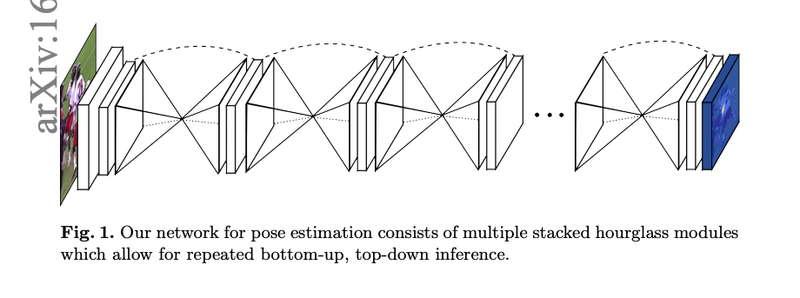


In [9]:
import torch
import torch.nn as nn

class StackedHourglassNetwork(nn.Module):
    def __init__(self, input_shape=(256, 256, 3), num_stack=4, num_residual=1, num_heatmap=16):
        super(StackedHourglassNetwork, self).__init__()
        self.num_stack = num_stack

        in_channels = input_shape[2]  # 3
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)

        # Bottleneck blocks 초기화
        # BottleneckBlock의 첫번째 호출: 64 → 128, downsample=True
        self.bottleneck1 = BottleneckBlock(in_channels=64, filters=128, stride=1, downsample=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # 두 번째: 128 → 128, downsample=False
        self.bottleneck2 = BottleneckBlock(in_channels=128, filters=128, stride=1, downsample=False)
        # 세 번째: 128 → 256, downsample=True
        self.bottleneck3 = BottleneckBlock(in_channels=128, filters=256, stride=1, downsample=True)

        # 스택 구성 요소들
        self.hourglass_modules = nn.ModuleList()
        self.residual_modules = nn.ModuleList()  # hourglass 후 residual block들 (num_residual회)
        self.linear_layers = nn.ModuleList()
        self.heatmap_convs = nn.ModuleList()
        # 마지막 스택을 제외한 중간 피쳐 결합용 1x1 conv
        self.intermediate_convs = nn.ModuleList()
        self.intermediate_outs = nn.ModuleList()

        for i in range(num_stack):
            # order=4인 hourglass 모듈 (앞에서 정의한 HourglassModule 사용)
            self.hourglass_modules.append(HourglassModule(order=4, filters=256, num_residual=num_residual))
            # hourglass 후 residual block들
            self.residual_modules.append(nn.Sequential(*[
                BottleneckBlock(in_channels=256, filters=256, stride=1, downsample=False)
                for _ in range(num_residual)
            ]))
            # Linear layer: 1x1 conv + BN + ReLU (앞에서 정의한 LinearLayer 사용)
            self.linear_layers.append(LinearLayer(in_channels=256, out_channels=256))
            # 최종 heatmap을 생성하는 1x1 conv
            self.heatmap_convs.append(nn.Conv2d(256, num_heatmap, kernel_size=1, stride=1, padding=0))

            if i < num_stack - 1:
                self.intermediate_convs.append(nn.Conv2d(256, 256, kernel_size=1, stride=1, padding=0))
                self.intermediate_outs.append(nn.Conv2d(num_heatmap, 256, kernel_size=1, stride=1, padding=0))

    def forward(self, x):
        # x: (B, 3, H, W)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.bottleneck1(x)
        x = self.pool(x)
        x = self.bottleneck2(x)
        x = self.bottleneck3(x)

        outputs = []
        for i in range(self.num_stack):
            hg = self.hourglass_modules[i](x)
            res = self.residual_modules[i](hg)
            lin = self.linear_layers[i](res)
            heatmap = self.heatmap_convs[i](lin)
            outputs.append(heatmap)

            if i < self.num_stack - 1:
                inter1 = self.intermediate_convs[i](lin)
                inter2 = self.intermediate_outs[i](heatmap)
                x = inter1 + inter2  # 다음 스택의 입력으로 사용

        return outputs

print('슝=3')

슝=3


# 7. 학습 엔진 만들기
GPU가 여러 개인 환경
이제 모델 학습을 진행할 차례입니다. 



그런데 학습을 할 수 있는 GPU가 여러 개이고 데이터를 병렬로 학습시키려면 어떻게 해야할까요? 여러 GPU를 사용하기 위해서는 약간의 코드를 추가해줘야 합니다. 학습 환경은 GPU가 하나이지만 나중에 기업 환경에서 여러 GPU를 사용할 수 있으니 살짝 공부해 봅시다.


데이터 병렬 처리 (Data Parallelism)

가장 핵심 키워드는 torch.nn.DataParallel입니다. 한 컴퓨터에 GPU가 여러 개인 경우 사용할 수 있는 방법인데요. 여러 GPU가 모델을 학습한 후 각각의 Loss를 계산하면 CPU가 전체 Loss를 종합합니다. 그런 후 모델의 가중치를 업데이트 하도록 하는 것이죠. 



각 GPU에서 계산한 Loss를 토대로 전체 Loss를 종합해주는 역할은 reduce() 함수가 담당합니다. 



이번에도 각 함수를 별개로 만들지 않고 하나의 객체로 만들어 봅니다.

실행 되었습니다.



In [10]:
import os
import math
import torch
import torch.nn as nn
import torch.optim as optim

class Trainer(object):
    def __init__(self,
                 model,
                 epochs,
                 global_batch_size,
                 initial_learning_rate):
        """
        - model: 학습시킬 PyTorch 모델(nn.Module)
        - epochs: 전체 학습 epoch 수
        - global_batch_size: 전체 배치 크기 (loss 계산 시 사용)
        - initial_learning_rate: 초기 학습률
        """
        self.model = model
        self.epochs = epochs
        self.global_batch_size = global_batch_size

        # MSE loss를 reduction='none'으로 사용 (가중치 적용을 위해)
        self.loss_object = nn.MSELoss(reduction='none')

        # Adam optimizer 초기화
        self.optimizer = optim.Adam(self.model.parameters(), lr=initial_learning_rate)

        # 학습률 스케줄링 관련 변수들
        self.current_learning_rate = initial_learning_rate
        self.last_val_loss = math.inf
        self.lowest_val_loss = math.inf
        self.patience_count = 0
        self.max_patience = 10

        # 최적 모델 체크포인트 저장
        self.best_model = None

        # 단일 GPU/멀티 GPU(DataParallel) 설정
        if torch.cuda.device_count() > 1:
            print(f"멀티 GPU 사용 (GPU 개수: {torch.cuda.device_count()})")
            self.model = nn.DataParallel(self.model)
        else:
            print("단일 GPU 혹은 CPU 사용")

    def lr_decay(self):
        """
        patience_count가 max_patience를 넘으면 학습률을 1/10으로 감소,
        그렇지 않고 val_loss가 그대로면 patience_count += 1,
        새 최저 val_loss를 달성하면 patience_count를 0으로.
        """
        if self.patience_count >= self.max_patience:
            self.current_learning_rate /= 10.0
            self.patience_count = 0
        elif self.last_val_loss == self.lowest_val_loss:
            self.patience_count = 0

        self.patience_count += 1

        # optimizer의 learning rate 갱신
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.current_learning_rate

    def lr_decay_step(self, epoch):
        """
        25, 50, 75 epoch에서 학습률을 1/10으로 감소시키는 스케줄링.
        """
        if epoch in [25, 50, 75]:
            self.current_learning_rate /= 10.0

        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.current_learning_rate

    def compute_loss(self, labels, outputs):
        """
        여러 스택의 heatmap 출력(outputs)에 대해 MSE를 구하되,
        labels > 0인 위치에는 81의 추가 가중치를 적용.
        """
        loss = 0
        for output in outputs:
            # labels > 0 이면 81 + 1 = 82, 아니면 1
            weights = (labels > 0).float() * 81 + 1
            squared_error = (labels - output) ** 2
            weighted_error = squared_error * weights
            # 전체 배치에 대한 평균 후, global_batch_size로 나눔
            loss += weighted_error.mean() / self.global_batch_size
        return loss

    def train_step(self, images, labels, device):
        self.model.train()
        images = images.to(device)
        labels = labels.to(device)

        self.optimizer.zero_grad()
        outputs = self.model(images)
        loss = self.compute_loss(labels, outputs)
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def val_step(self, images, labels, device):
        self.model.eval()
        with torch.no_grad():
            images = images.to(device)
            labels = labels.to(device)
            outputs = self.model(images)
            loss = self.compute_loss(labels, outputs)
        return loss.item()

    def run(self, train_loader, val_loader, device):
        """
        - train_loader, val_loader: PyTorch DataLoader
        - device: torch.device('cuda' or 'cpu')
        """
        for epoch in range(1, self.epochs + 1):
            # 학습률 감소 로직
            self.lr_decay()
            print(f"Start epoch {epoch} with learning rate {self.current_learning_rate:.6f}")

            # Training
            total_train_loss = 0.0
            num_train_batches = 0
            for images, labels in train_loader:
                batch_loss = self.train_step(images, labels, device)
                total_train_loss += batch_loss
                num_train_batches += 1
                print(f"[Train] batch {num_train_batches} loss {batch_loss:.4f} "
                      f"avg_loss {total_train_loss/num_train_batches:.4f}")
            train_loss = total_train_loss / num_train_batches
            print(f"Epoch {epoch} train loss {train_loss:.4f}")

            # Validation
            total_val_loss = 0.0
            num_val_batches = 0
            for images, labels in val_loader:
                batch_loss = self.val_step(images, labels, device)
                num_val_batches += 1
                print(f"[Val] batch {num_val_batches} loss {batch_loss:.4f}")
                # NaN이 아닌 경우만 합산
                if not math.isnan(batch_loss):
                    total_val_loss += batch_loss
                else:
                    num_val_batches -= 1

            if num_val_batches > 0:
                val_loss = total_val_loss / num_val_batches
            else:
                val_loss = float('nan')

            print(f"Epoch {epoch} val loss {val_loss:.4f}")

            # 새로운 최저 val_loss 달성 시 모델 저장
            if val_loss < self.lowest_val_loss:
                self.save_model(epoch, val_loss)
                self.lowest_val_loss = val_loss
            self.last_val_loss = val_loss

        return self.best_model

    def save_model(self, epoch, loss):
        model_name = os.path.join(MODEL_PATH, f'model-epoch-{epoch}-loss-{loss:.4f}.pt')
        torch.save(self.model.state_dict(), model_name)
        self.best_model = model_name
        print(f"Model {model_name} saved.")

print('슝=3')

슝=3


### Q. PyTorch의 GPU 분산 훈련을 위한 전략 메소드는 또 무엇이 있는지 알아볼까요?
공유해주신 강의 페이지에서 언급된 `torch.nn.DataParallel` (DP) 외에도, PyTorch에서는 멀티 GPU 및 대규모 분산 훈련을 위해 더 강력하고 효율적인 다양한 전략 메소드(모듈)들을 제공하고 있습니다.

실무 및 기업 환경에서 가장 많이 쓰이는 핵심 분산 훈련 전략들을 정리해 드릴게요.

---

### 1. `torch.nn.parallel.DistributedDataParallel` (DDP)

실무에서 멀티 GPU를 사용할 때 **가장 표준적으로 권장되는 메소드**입니다.

* **작동 방식:** 단일 프로세스에서 멀티 스레드로 GPU를 제어하는 DP와 달리, DDP는 각 GPU마다 독립적인 프로세스(Multi-Process)를 생성하여 데이터를 병렬 처리합니다.
* **장점:** * 파이썬의 GIL(Global Interpreter Lock) 병목 현상이 발생하지 않아 DP보다 **연산 효율과 훈련 속도가 훨씬 빠릅니다.**
* 한 컴퓨터(Single-Node)뿐만 아니라 **여러 대의 컴퓨터(Multi-Node) 환경**에서도 GPU를 묶어 확장(Scaling)할 수 있습니다.



### 2. `torch.distributed.pipelining` (Pipeline Parallelism)

모델의 크기가 너무 커서 단일 GPU의 메모리에 올릴 수 없을 때 사용하는 **모델 병렬화(Model Parallelism)** 전략 중 하나입니다.

* **작동 방식:** 모델의 레이어들을 순차적으로 쪼개어 서로 다른 GPU에 배치한 뒤, 데이터가 파이프라인(공장 컨베이어 벨트)처럼 GPU들을 거쳐 가며 순방향/역방향 연산을 수행하게 합니다.

### 3. FSDP (`torch.distributed.fsdp.FullyShardedDataParallel`)

DeepSpeed의 ZeRO 기술과 유사하게 PyTorch 1.11부터 공식 도입된 **최신 대규모 분산 훈련 전략**입니다. LLM(대규모 언어 모델) 등 초대형 모델을 학습할 때 필수적으로 사용됩니다.

* **작동 방식:** 기존 DDP는 모든 GPU가 모델의 가중치(Weights)와 Optimizer 상태를 똑같이 복사해서 가집니다. 반면 FSDP는 이 **모델 파라미터, 그래디언트, 옵티마이저 상태를 모든 GPU에 쪼개서 분산(Sharding) 저장**합니다.
* **장점:** GPU 메모리를 극적으로 아낄 수 있어서, 수십~수백억 개의 파라미터를 가진 거대 모델도 메모리 초과(OOM) 없이 효율적으로 분산 학습을 진행할 수 있습니다.

---

> 💡 **퀴즈 답변 한 줄 요약**
> 단일 노드 멀티 GPU 환경에서 가장 널리 쓰이는 고성능 프로세스 기반의 **`DistributedDataParallel (DDP)`**과, 초거대 모델 학습을 위해 메모리를 최적화해 분산하는 **`FullyShardedDataParallel (FSDP)`** 등이 있습니다.
> 

이제 데이터셋을 만드는 함수를 작성합니다. .pt 파일이 여러개이므로 torch.utils.data.DataLoader를 통해 불러옵니다.

In [11]:
from torch.utils.data import DataLoader

IMAGE_SHAPE = (256, 256, 3)
HEATMAP_SIZE = (64, 64)

def create_dataloader(annotation_file, image_dir, batch_size, num_heatmap, is_train=True):
    """
    annotation_file: JSON 파일 경로 (예: train.json)
    image_dir: 이미지 파일들이 저장된 디렉토리 경로
    batch_size: 배치 크기
    num_heatmap: 생성할 heatmap 개수
    is_train: True이면 shuffle 적용
    """

    preprocess = Preprocessor(
        image_shape=IMAGE_SHAPE,
        heatmap_shape=(HEATMAP_SIZE[0], HEATMAP_SIZE[1], num_heatmap),
        is_train=is_train
    )

    dataset = MPIIDataset(annotation_file=annotation_file, image_dir=image_dir, transform=preprocess)

    # DataLoader 생성
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=is_train,
        num_workers=4,
        pin_memory=True,
        drop_last=False,
        prefetch_factor=2
    )

    return dataloader

이제 데이터셋과 모델, 훈련용 객체를 조립만하면 되겠군요. 하나의 함수로 만들어 주겠습니다.

In [12]:
def train(epochs, learning_rate, num_heatmap, batch_size, train_annotation_file, val_annotation_file, image_dir):
    """
    - epochs: 전체 학습 epoch 수
    - learning_rate: 초기 학습률
    - num_heatmap: 생성할 heatmap 개수
    - batch_size: 배치 크기
    - train_annotation_file: train.json 파일 경로
    - val_annotation_file: validation.json 파일 경로
    - image_dir: 이미지 파일들이 저장된 디렉토리 경로
    """
    global_batch_size = batch_size

    train_loader = create_dataloader(train_annotation_file, image_dir, batch_size, num_heatmap, is_train=True)
    val_loader = create_dataloader(val_annotation_file, image_dir, batch_size, num_heatmap, is_train=False)

    if not os.path.exists(MODEL_PATH):
        os.makedirs(MODEL_PATH)

    model = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=num_heatmap)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    trainer = Trainer(
        model,
        epochs,
        global_batch_size,
        initial_learning_rate=learning_rate
    )

    print("Start training...")
    return trainer.run(train_loader, val_loader, device)

print('슝=3')

슝=3


이제 꽤 어려웠던 모든 준비가 끝났군요. 모델을 학습시킬 차례입니다. 학습에는 오랜 시간이 걸리기 때문에 여기서는 동작하는 코드만 확인해봅시다. (1 Epoch 학습에만 1 시간 가까이 소요됩니다.😮)

In [13]:
# %%time
# # 아래 코드를 실행하면 직접 학습을 해볼 수 있습니다.
# import os

# TRAIN_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'train.json')
# VAL_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'validation.json')
# IMAGE_DIR = os.path.join(PROJECT_PATH, 'images')

# epochs = 2
# batch_size = 2
# num_heatmap = 16
# learning_rate = 0.0007

# best_model_file = train(epochs, learning_rate, num_heatmap, batch_size, TRAIN_JSON, VAL_JSON, IMAGE_DIR)

# 8. 둠칫둠칫 댄스타임
예측 엔진 만들기
이제 학습이 끝난 모델이 얼마나 잘 예측하는지 확인해 볼 시간입니다. 미리 학습된 모델을 불러옵시다.

In [14]:
!pip install gdown

In [15]:
import gdown

file_id = "1-F6ztKRSL7Lp0kVT7nPuSIfEpBWz1abZ"
output_path = "model-epoch-2-loss-1.2050.pt"
gdown.download(f"https://drive.google.com/uc?id={file_id}", output_path, quiet=False)
!mv model-epoch-2-loss-1.2050.pt work/mpii/models

epochs = 2
batch_size = 16
num_heatmap = 16
learning_rate = 0.0007

Downloading...
From (original): https://drive.google.com/uc?id=1-F6ztKRSL7Lp0kVT7nPuSIfEpBWz1abZ
From (redirected): https://drive.google.com/uc?id=1-F6ztKRSL7Lp0kVT7nPuSIfEpBWz1abZ&confirm=t&uuid=c7152f31-8bff-4fd5-8079-fc51b7e1e115
To: /home/jovyan/work/projects/AIFFEL_quest_rs/GoingDeeper/Quest04/model-epoch-2-loss-1.2050.pt
100%|██████████| 65.9M/65.9M [00:01<00:00, 33.2MB/s]


In [16]:
PROJECT_PATH = 'work/mpii'
WEIGHTS_PATH = os.path.join(PROJECT_PATH, 'models', 'model-epoch-2-loss-1.2050.pt')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=num_heatmap)
model.to(device)
checkpoint = torch.load(WEIGHTS_PATH, map_location=device)
model.load_state_dict(checkpoint)
model.eval() # 평가 모드로 변경

# 이전의 학습하는 코드 블럭을 통해 학습하고 그 모델을 사용할 경우 아래 주석 처리된 코드를 사용하면 됩니다
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=num_heatmap)
# model.to(device)
# checkpoint = torch.load(best_model_file, map_location=device)
# model.load_state_dict(checkpoint)
# model.eval()

StackedHourglassNetwork(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (bottleneck1): BottleneckBlock(
    (downsample_conv): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (conv3): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck2

학습에 사용했던 keypoint 들을 사용해야 하기 때문에 필요한 변수를 지정해 줍니다. 변수에 저장되는 것은 해당 부위를 나타내는 인덱스예요.

In [17]:
R_ANKLE = 0
R_KNEE = 1
R_HIP = 2
L_HIP = 3
L_KNEE = 4
L_ANKLE = 5
PELVIS = 6
THORAX = 7
UPPER_NECK = 8
HEAD_TOP = 9
R_WRIST = 10
R_ELBOW = 11
R_SHOULDER = 12
L_SHOULDER = 13
L_ELBOW = 14
L_WRIST = 15

MPII_BONES = [
    [R_ANKLE, R_KNEE],
    [R_KNEE, R_HIP],
    [R_HIP, PELVIS],
    [L_HIP, PELVIS],
    [L_HIP, L_KNEE],
    [L_KNEE, L_ANKLE],
    [PELVIS, THORAX],
    [THORAX, UPPER_NECK],
    [UPPER_NECK, HEAD_TOP],
    [R_WRIST, R_ELBOW],
    [R_ELBOW, R_SHOULDER],
    [THORAX, R_SHOULDER],
    [THORAX, L_SHOULDER],
    [L_SHOULDER, L_ELBOW],
    [L_ELBOW, L_WRIST]
]

print('슝=3')

슝=3


모델을 학습할 때 라벨이 되는 좌표를 heatmap으로 바꿨던 것이 기억 나시나요? 학습을 heatmap으로 했기 때문에 모델이 추론해 내놓은 결과도 heatmap입니다. 그래서 이 heatmap으로부터 좌표를 추출해야해요. heatmap중에 최대값을 갖는 지점을 찾아내면 되겠네요. heatmap에서 최대값을 찾는 함수를 만들어 줍니다.

In [18]:
def find_max_coordinates(heatmaps):
    # heatmaps: (H, W, C)
    H, W, C = heatmaps.shape
    # reshape to (H*W, C)
    flatten_heatmaps = heatmaps.reshape(-1, C)
    # 각 채널 별 최대값 인덱스 (flattened index)
    indices = torch.argmax(flatten_heatmaps, dim=0)
    # y 좌표: index // H, x 좌표: index - H * y
    y = indices // H
    x = indices - H * y
    # 반환: (C, 2) 텐서, 각 행이 [x, y] 좌표
    return torch.stack([x, y], dim=1)
print("슝=3")

슝=3


위 함수만으로는 256x256 이미지에 64x64 heatmap max 값을 표현할 때 quantization 오차가 발생하기 때문에 실제 계산에서는 3x3 필터를 이용해서 근사치를 구해줍니다.

In [19]:
def extract_keypoints_from_heatmap(heatmaps):
    """
    heatmaps: (H, W, C) 텐서 (예: (64,64,16))
    """
    H, W, C = heatmaps.shape
    max_keypoints = find_max_coordinates(heatmaps)  # shape: (C, 2) with [x, y] per channel

    # pad heatmaps: 먼저 (C, H, W)로 변환한 후 pad, 다시 (H+2, W+2, C)
    heatmaps_permuted = heatmaps.permute(2, 0, 1)  # (C, H, W)
    padded = F.pad(heatmaps_permuted, (1, 1, 1, 1))  # pad (left, right, top, bottom)
    padded_heatmaps = padded.permute(1, 2, 0)  # (H+2, W+2, C)

    adjusted_keypoints = []
    for i, keypoint in enumerate(max_keypoints):
        # 기존 keypoint의 좌표에 패딩 오프셋 추가
        max_x = int(keypoint[0].item()) + 1
        max_y = int(keypoint[1].item()) + 1

        # 3x3 패치를 추출 (채널 i)
        patch = padded_heatmaps[max_y-1:max_y+2, max_x-1:max_x+2, i]  # (3,3)
        # 중앙 값 제거
        patch[1, 1] = 0
        # 패치 내 최대값의 index를 찾음
        flat_patch = patch.reshape(-1)
        index = torch.argmax(flat_patch).item()

        next_y = index // 3
        next_x = index % 3
        delta_y = (next_y - 1) / 4.0
        delta_x = (next_x - 1) / 4.0

        adjusted_x = keypoint[0].item() + delta_x
        adjusted_y = keypoint[1].item() + delta_y
        adjusted_keypoints.append((adjusted_x, adjusted_y))

    # 리스트를 텐서로 변환하고 clip
    adjusted_keypoints = torch.tensor(adjusted_keypoints)
    adjusted_keypoints = torch.clamp(adjusted_keypoints, 0, H)
    normalized_keypoints = adjusted_keypoints / H
    return normalized_keypoints

print('슝=3')

슝=3


이제 모델과 이미지 경로를 입력하면 이미지와 keypoint를 출력하는 함수를 만들어 줍니다. 편리하게 사용할 수 있도록이요.

In [20]:
import torch
from PIL import Image
import torchvision.transforms as transforms

def predict(model, image_path):
    # 이미지 로드 (RGB 모드)
    image = Image.open(image_path).convert("RGB")

    # 전처리: 리사이즈, 텐서 변환, [-1, 1] 범위로 스케일링
    preprocess = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),         # 결과: [0, 1]
        transforms.Lambda(lambda x: x * 2 - 1)  # [0,1] -> [-1,1]
    ])
    inputs = preprocess(image)          # shape: (C, H, W)
    inputs = inputs.unsqueeze(0)        # 배치 차원 추가: (1, C, H, W)

    # 모델의 device에 맞게 입력을 이동시킵니다.
    device = next(model.parameters()).device
    inputs = inputs.to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(inputs)         # outputs가 리스트가 아닐 수 있음

    if not isinstance(outputs, list):
        outputs = [outputs]

    # 마지막 스택의 결과를 사용한다고 가정 (출력 shape: (1, num_heatmap, H, W))
    heatmap_tensor = outputs[-1].squeeze(0)      # (num_heatmap, H, W)
    # extract_keypoints_from_heatmap 함수는 (H, W, num_heatmap) 형태를 기대하므로 차원 순서를 변경
    heatmap_tensor = heatmap_tensor.permute(1, 2, 0)  # (H, W, num_heatmap)

    # detach, CPU로 이동 후 extract_keypoints_from_heatmap에 전달
    heatmap = heatmap_tensor.detach().cpu()
    kp = extract_keypoints_from_heatmap(heatmap)

    return image, kp

print('슝=3')

슝=3


거의 다 온 것 같습니다. 이제 그림만 그려주면 완성될 것 같네요. 그림을 그릴 때는 두 가지 그림을 그려볼 겁니다. keypoint들과 뼈대입니다. keypoint들은 관절 역할을 하고 keypoint들을 연결시킨 것이 뼈대가 되겠네요. 



세 가지 함수를 각각 작성해 줍니다.

In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def to_numpy_image(image):
    if torch.is_tensor(image):
        image_np = image.detach().cpu().numpy()
        # 이미지 채널이 첫 번째 차원이라면, (C, H, W) -> (H, W, C)
        if image_np.ndim == 3 and image_np.shape[0] == 3:
            image_np = np.transpose(image_np, (1, 2, 0))
    elif not isinstance(image, np.ndarray):
        # PIL.Image인 경우
        image_np = np.array(image)
    else:
        image_np = image
    return image_np

def draw_keypoints_on_image(image, keypoints, index=None):
    image_np = to_numpy_image(image)

    fig, ax = plt.subplots(1)
    ax.imshow(image_np)
    for i, joint in enumerate(keypoints):
        joint_x = joint[0] * image_np.shape[1]
        joint_y = joint[1] * image_np.shape[0]
        if index is not None and index != i:
            continue
        ax.scatter(joint_x, joint_y, s=10, c='red', marker='o')
    plt.show()

def draw_skeleton_on_image(image, keypoints, index=None):
    image_np = to_numpy_image(image)

    fig, ax = plt.subplots(1)
    ax.imshow(image_np)
    joints = []
    for i, joint in enumerate(keypoints):
        joint_x = joint[0] * image_np.shape[1]
        joint_y = joint[1] * image_np.shape[0]
        joints.append((joint_x, joint_y))

    for bone in MPII_BONES:
        joint_1 = joints[bone[0]]
        joint_2 = joints[bone[1]]
        ax.plot([joint_1[0], joint_2[0]], [joint_1[1], joint_2[1]], linewidth=5, alpha=0.7)
    plt.show()

print('슝=3')

슝=3


In [22]:
# 기본 제공 이미지입니다. 다른 사진으로 바꿔보세요!
!wget "https://images.unsplash.com/photo-1546427660-eb346c344ba5?q=80&w=2787&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D" -O work/mpii/test_image.jpg

--2026-07-08 08:11:14--  https://images.unsplash.com/photo-1546427660-eb346c344ba5?q=80&w=2787&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D
Resolving images.unsplash.com (images.unsplash.com)... 151.101.2.208, 151.101.66.208, 151.101.130.208, ...
Connecting to images.unsplash.com (images.unsplash.com)|151.101.2.208|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1058994 (1.0M) [image/jpeg]
Saving to: ‘work/mpii/test_image.jpg’

work/mpii/test_imag 100%[===================>]   1.01M  4.70MB/s    in 0.2s    

2026-07-08 08:11:15 (4.70 MB/s) - ‘work/mpii/test_image.jpg’ saved [1058994/1058994]



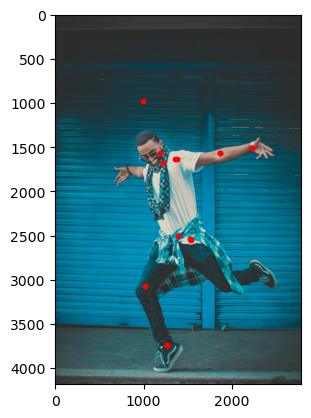

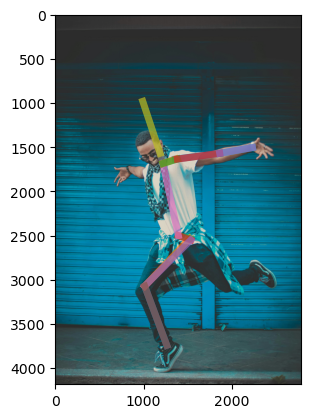

In [23]:
import os

test_image = os.path.join(PROJECT_PATH, 'test_image.jpg')

image, keypoints = predict(model, test_image)
draw_keypoints_on_image(image, keypoints)
draw_skeleton_on_image(image, keypoints)

# 9. 프로젝트: 모델 바꿔보기
라이브러리 버전 확인
프로젝트에 사용할 주요 라이브러리 버전을 확인해봅니다.

In [6]:
!pip install ray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 MB 48.8 MB/s eta 0:00:0000:0100:01


In [7]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [8]:
import torch
import numpy as np
import PIL
import ray

print(torch.__version__)
print(np.__version__)
print(PIL.__version__)
print(ray.__version__)

2.7.1+cu118
2.2.6
11.2.1
2.56.0


simplebaseline 모델로 변경해 봅시다
지금까지 우리는 StackedHourglass Network 기반으로 학습을 진행해 왔습니다.



그러나 지난 시간에 살펴본 것처럼 Simplebaseline 모델은 이보다 훨씬 간단한 모델 구조에도 불구하고 더욱 좋은 성능을 보여주었던 바 있습니다.



실제로도 그런 성능을 얻을 수 있을지 확인해 보겠습니다.

# STEP 1 : simplebaseline 모델 완성하기
simplebaseline.py 파일과 이전에 살펴본 Simplebaseline 내용을 참고하여 모델을 완성합니다.


In [ ]:
# ==========================================
# 1. Dataset & DataLoader 구현 (크기 불일치 수정 버전)
# ==========================================
import os
import json
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

class MPIIDataset(Dataset):
    def __init__(self, json_file, img_dir, img_size=(256, 256), num_heatmap=16, sigma=2):
        self.img_dir = img_dir
        self.img_size = img_size
        self.num_heatmap = num_heatmap
        self.sigma = sigma
        
        # 중요: 모델의 최종 출력 크기인 64x64에 맞추어 Heatmap target 크기를 지정합니다.
        self.heatmap_size = (64, 64) 
        
        with open(json_file, 'r') as f:
            self.data = json.load(f)
            
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.data)

    def _generate_heatmap(self, joints, joints_vis):
        # 모델 출력 크기인 64x64 크기로 빈 맵 생성
        w, h = self.heatmap_size
        target = np.zeros((self.num_heatmap, h, w), dtype=np.float32)
        
        for i in range(self.num_heatmap):
            if joints_vis[i] == 0 or joints[i][0] < 0 or joints[i][1] < 0:
                continue
                
            x, y = int(joints[i][0]), int(joints[i][1])
            
            # 64x64 경계를 벗어나는지 체크
            if x >= w or y >= h:
                continue
                
            # Gaussian peak 생성
            grid_y, grid_x = np.mgrid[0:h, 0:w]
            dist = (grid_x - x) ** 2 + (grid_y - y) ** 2
            heatmap = np.exp(-dist / (2 * self.sigma ** 2))
            target[i] = heatmap
            
        return torch.from_numpy(target)

    def __getitem__(self, idx):
        item = self.data[idx]
        img_path = os.path.join(self.img_dir, item['image'])
        
        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f"이미지를 찾을 수 없습니다: {img_path}")
            
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape
        img = cv2.resize(img, self.img_size) # 입력 이미지는 원래대로 256x256 리사이즈
        
        img_tensor = self.transform(img)
        
        joints = item['joints']
        joints_vis = item['joints_vis']
        
        # [핵심 수정]: 좌표 스케일링을 원본 이미지 크기(w, h)에서 
        # 모델 입력(256)이 아닌 최종 Heatmap 크기(64x64) 비율로 직접 변환합니다.
        scaled_joints = []
        for joint in joints:
            scaled_x = joint[0] * (self.heatmap_size[0] / w)
            scaled_y = joint[1] * (self.heatmap_size[1] / h)
            scaled_joints.append([scaled_x, scaled_y])
            
        # 16개 채널의 64x64 크기 Heatmap 생성
        heatmap_tensor = self._generate_heatmap(scaled_joints, joints_vis)
        
        return img_tensor, heatmap_tensor

print("Step 1 수정 완료: 모델 출력 규격(64x64)에 맞춰 Heatmap 크기 조정 완료")

Step 1 수정 완료: 모델 출력 규격(64x64)에 맞춰 Heatmap 크기 조정 완료



# STEP 2 : simplebaseline 모델로 변경하여 훈련하기
StackedHourglass를 학습시킨 코드의 모델 선언 부분을 simplebaseline 모델로 변경한 후 다시 학습을 진행합니다.


In [10]:
# ==========================================
# 2. SimpleBaseline 모델 및 Loss 정의
# ==========================================
import torch.nn as nn
import torchvision.models as models

class SimpleBaseline(nn.Module):
    def __init__(self, num_heatmap=16):
        super(SimpleBaseline, self).__init__()
        # Backbone으로 ResNet50 로드 (가장 최신 PyTorch 권장 방식 적용)
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2]) # 출력 채널 수: 2048
        
        # Upsampling Layers (Transposed Convolution 3개층으로 256x256 해상도 복원)
        self.deconv_layers = nn.Sequential(
            nn.ConvTranspose2d(2048, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True)
        )
        
        # 최종 Heatmap 채널 수(16)로 매핑하는 레이어
        self.final_layer = nn.Conv2d(256, num_heatmap, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        x = self.backbone(x)
        x = self.deconv_layers(x)
        x = self.final_layer(x)
        return x

# Loss Function: 예측된 Heatmap과 Ground-Truth의 오차 계산용 MSE
criterion = nn.MSELoss()

print("Step 2 완료: SimpleBaseline 모델 및 Loss 함수 정의 완료")

Step 2 완료: SimpleBaseline 모델 및 Loss 함수 정의 완료



# STEP 3 : 두 모델의 비교 
실습에서 다룬 StackedHourglass Network와 Simplebaseline 모델을 둘 다 동일한 Epoch 수만큼 학습하여 그 결과를 비교해 봅니다.



In [15]:
# ==========================================
# 3. 직접 실행 및 테스트 스크립트 (시각화 기능 포함)
# ==========================================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random

def visualize_result(image, gt_heatmap, pred_heatmap, epoch):
    """
    중간 결과를 확인하기 위해 이미지, GT 관절, 예측 관절을 시각화합니다.
    """
    # 텐서 역정규화 (Normalize 해제) 및 넘파이 변환
    img = image.cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = np.clip((img * std + mean) * 255, 0, 255).astype(np.uint8)
    
    # Heatmap에서 가장 높은 확률값을 가진 좌표(Argmax) 추출
    # gt_heatmap, pred_heatmap 크기: [16, 64, 64]
    gt_heatmap = gt_heatmap.cpu().numpy()
    pred_heatmap = pred_heatmap.cpu().numpy()
    
    num_joints = gt_heatmap.shape[0]
    
    plt.figure(figsize=(10, 5))
    
    # 1. Ground Truth 시각화
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Epoch {epoch} - Ground Truth")
    for i in range(num_joints):
        hm = gt_heatmap[i]
        if hm.max() > 0.1: # 유효한 관절만 표시
            y, x = np.unravel_index(np.argmax(hm), hm.shape)
            # 64x64 좌표를 이미지 크기인 256x256으로 복원 시각화
            plt.scatter(x * 4, y * 4, c='red', s=20)
            
    # 2. Model Prediction 시각화
    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.title(f"Epoch {epoch} - Prediction")
    for i in range(num_joints):
        hm = pred_heatmap[i]
        if hm.max() > 0.1: # 일정 임계값 이상인 경우만 표시
            y, x = np.unravel_index(np.argmax(hm), hm.shape)
            plt.scatter(x * 4, y * 4, c='blue', s=20)
            
    plt.show()

def train_simplebaseline(epochs, learning_rate, num_heatmap, batch_size, train_json, val_json, image_dir):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"현재 활성화된 학습 디바이스: {device}")
    
    train_dataset = MPIIDataset(train_json, image_dir, num_heatmap=num_heatmap)
    val_dataset = MPIIDataset(val_json, image_dir, num_heatmap=num_heatmap)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    
    model = SimpleBaseline(num_heatmap=num_heatmap).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # Loss 기록용 리스트
    history = {'train_loss': [], 'val_loss': []}
    
    best_val_loss = float('inf')
    best_model_path = 'best_comparison_model.pth'
    
    for epoch in range(1, epochs + 1):
        # --- Training Pass ---
        model.train()
        train_loss = 0.0
        for images, heatmaps in train_loader:
            images, heatmaps = images.to(device), heatmaps.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, heatmaps)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
        train_loss /= len(train_loader.dataset)
        
        # --- Validation Pass ---
        model.eval()
        val_loss = 0.0
        sample_image, sample_gt, sample_pred = None, None, None
        
        with torch.no_grad():
            for idx, (images, heatmaps) in enumerate(val_loader):
                images, heatmaps = images.to(device), heatmaps.to(device)
                outputs = model(images)
                loss = criterion(outputs, heatmaps)
                val_loss += loss.item() * images.size(0)
                
                # 시각화를 위해 첫 번째 배치의 첫 번째 데이터 저장
                if idx == 0:
                    sample_image = images[0]
                    sample_gt = heatmaps[0]
                    sample_pred = outputs[0]
                    
        val_loss /= len(val_loader.dataset)
        
        # Loss 기록
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        
        print(f"\nEpoch [{epoch}/{epochs}] - Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
        
        # 중간 결과 시각화 출력
        if sample_image is not None:
            visualize_result(sample_image, sample_gt, sample_pred, epoch)
            
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f"--> [성능 개선] 모델 저장 완료: {best_model_path}")
            
    # --- 학습 종료 후 Loss 그래프 그리기 ---
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, epochs + 1), history['train_loss'], label='Train Loss', marker='o')
    plt.plot(range(1, epochs + 1), history['val_loss'], label='Val Loss', marker='o')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    print("슝=3 학습 및 시각화 프로세스가 완료되었습니다.")
    return best_model_path

print("Step 3 완료: 시각화 기능이 내장된 best_comparison_model 준비 완료")

Step 3 완료: 시각화 기능이 내장된 train_simplebaseline 준비 완료


현재 활성화된 학습 디바이스: cuda

Epoch [1/5] - Train Loss: 0.002686 | Val Loss: 0.002352


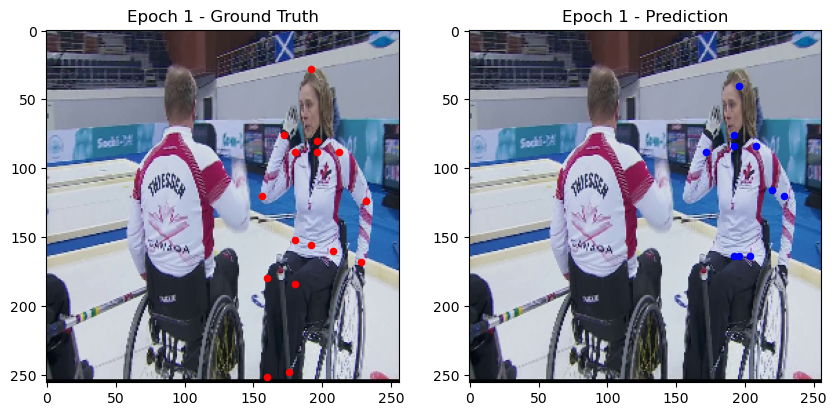

--> [성능 개선] 모델 저장 완료: best_simplebaseline_model.pth

Epoch [2/5] - Train Loss: 0.002240 | Val Loss: 0.002238


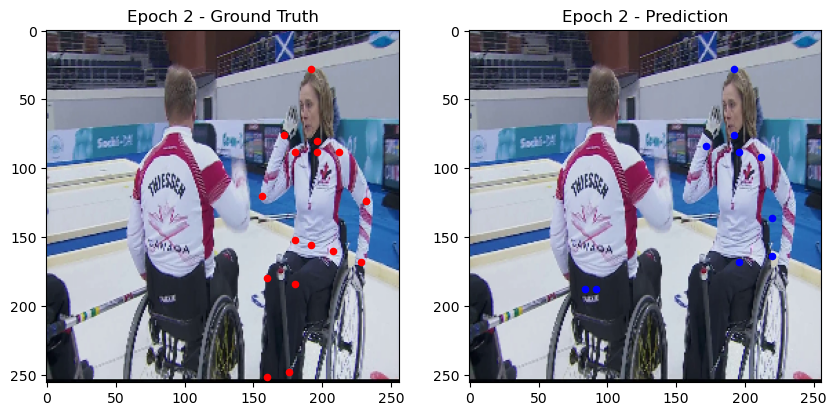

--> [성능 개선] 모델 저장 완료: best_simplebaseline_model.pth

Epoch [3/5] - Train Loss: 0.002127 | Val Loss: 0.002132


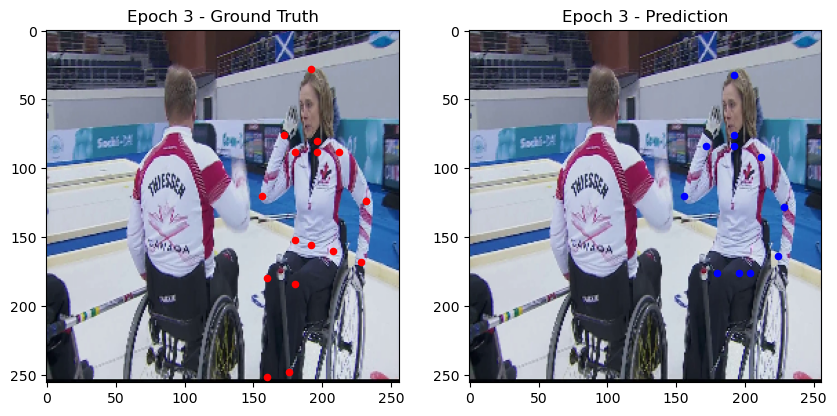

--> [성능 개선] 모델 저장 완료: best_simplebaseline_model.pth

Epoch [4/5] - Train Loss: 0.002029 | Val Loss: 0.002093


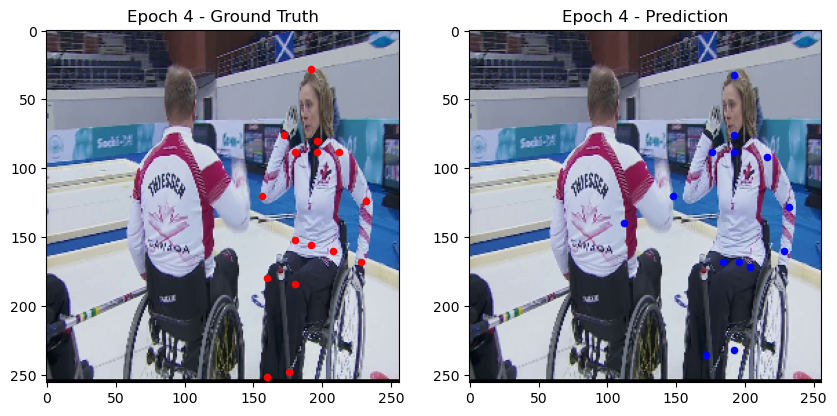

--> [성능 개선] 모델 저장 완료: best_simplebaseline_model.pth

Epoch [5/5] - Train Loss: 0.001958 | Val Loss: 0.002040


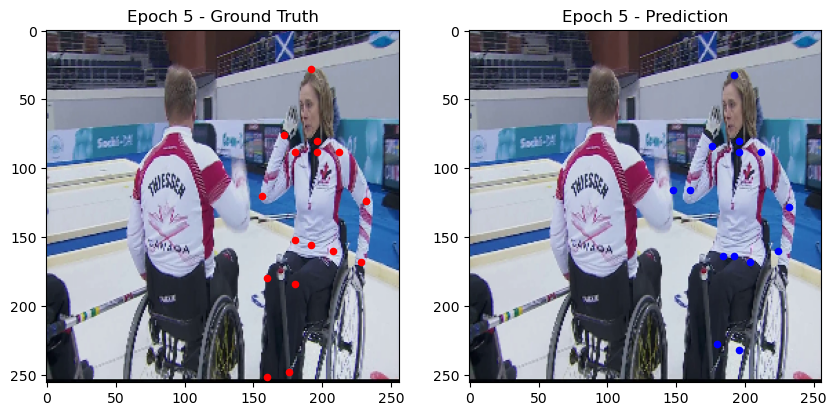

--> [성능 개선] 모델 저장 완료: best_simplebaseline_model.pth


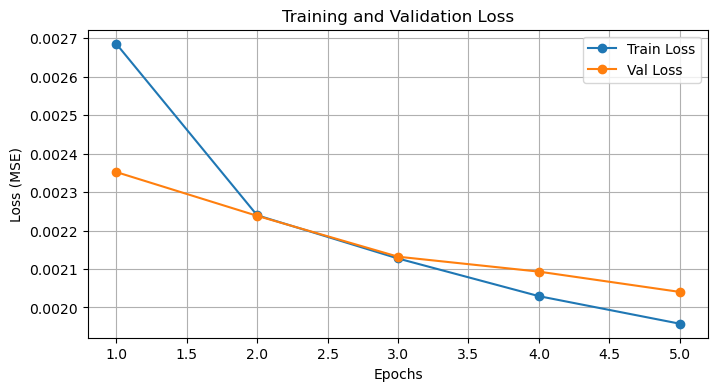

슝=3 학습 및 시각화 프로세스가 완료되었습니다.
CPU times: user 42min 58s, sys: 1min 13s, total: 44min 11s
Wall time: 45min 17s


In [49]:
%%time
import os

TRAIN_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'train.json')
VAL_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'validation.json')
IMAGE_DIR = os.path.join(PROJECT_PATH, 'images')

epochs = 5  
batch_size = 4  
num_heatmap = 16
learning_rate = 0.001  

best_model_file = train_simplebaseline(epochs, learning_rate, num_heatmap, batch_size, TRAIN_JSON, VAL_JSON, IMAGE_DIR)

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

def visualize_epoch_result(image, gt_heatmap, pred_heatmap, epoch):
    """
    매 에폭마다 Validation 데이터 중 1장의 이미지와 
    정답(GT) 관절 위치, 모델 예측 위치를 비교 시각화합니다.
    """
    # 1. 이미지 역정규화 및 변환 (ToTensor 및 Normalize 해제)
    img = image.cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = np.clip((img * std + mean) * 255, 0, 255).astype(np.uint8)
    
    gt_heatmap = gt_heatmap.cpu().numpy()
    pred_heatmap = pred_heatmap.cpu().numpy()
    num_joints = gt_heatmap.shape[0]
    
    plt.figure(figsize=(12, 6))
    
    # [왼쪽] Ground Truth (정답 위치)
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Epoch {epoch} - Ground Truth (Red)")
    for i in range(num_joints):
        hm = gt_heatmap[i]
        if hm.max() > 0.1: # 유효한 관절 필터링
            y, x = np.unravel_index(np.argmax(hm), hm.shape)
            # 64x64 해상도 좌표를 이미지 크기(256x256)인 4배 크기로 복원
            plt.scatter(x * 4, y * 4, c='red', s=25, edgecolors='black')
            
    # [오른쪽] Prediction (모델 예측 위치)
    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.title(f"Epoch {epoch} - Model Prediction (Blue)")
    for i in range(num_joints):
        hm = pred_heatmap[i]
        if hm.max() > 0.05: # 예측된 피크값이 존재하는 경우만 표시
            y, x = np.unravel_index(np.argmax(hm), hm.shape)
            plt.scatter(x * 4, y * 4, c='dodgerblue', s=25, edgecolors='black')
            
    plt.show()

def train(epochs, learning_rate, num_heatmap, batch_size, train_json, val_json, image_dir):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"학습 시작 장치: {device}")
    
    # 데이터셋 및 데이터로더 빌드 (기존에 정의한 MPIIDataset 활용)
    train_dataset = MPIIDataset(train_json, image_dir, num_heatmap=num_heatmap)
    val_dataset = MPIIDataset(val_json, image_dir, num_heatmap=num_heatmap)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    
    # 모델 및 옵티마이저 선언 (기존에 정의한 SimpleBaseline 활용)
    model = SimpleBaseline(num_heatmap=num_heatmap).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()
    
    # Loss 추적용 데이터 기록
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_model_path = 'best_simplebaseline_model.pth'
    
    for epoch in range(1, epochs + 1):
        # --- 1. Train Loop ---
        model.train()
        train_loss = 0.0
        for images, heatmaps in train_loader:
            images, heatmaps = images.to(device), heatmaps.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, heatmaps)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
        train_loss /= len(train_loader.dataset)
        
        # --- 2. Validation Loop ---
        model.eval()
        val_loss = 0.0
        
        # 에폭별 시각화를 위한 샘플링 변수
        sample_img, sample_gt, sample_pred = None, None, None
        
        with torch.no_grad():
            for idx, (images, heatmaps) in enumerate(val_loader):
                images, heatmaps = images.to(device), heatmaps.to(device)
                outputs = model(images)
                loss = criterion(outputs, heatmaps)
                val_loss += loss.item() * images.size(0)
                
                # 첫 번째 배치의 첫 번째 장 데이터를 시각화 대상으로 선정
                if idx == 0:
                    sample_img = images[0]
                    sample_gt = heatmaps[0]
                    sample_pred = outputs[0]
                    
        val_loss /= len(val_loader.dataset)
        
        # 기록 저장
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        
        # 결과 로그 프린트
        print(f"\n[Epoch {epoch}/{epochs}] Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
        
        # 실시간 이미지 중간 결과 시각화 출력 호출
        if sample_img is not None:
            visualize_epoch_result(sample_img, sample_gt, sample_pred, epoch)
            
        # 최우수 가중치 저장
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f"--> [성능 갱신] 최적 모델 저장 완료: {best_model_path}")
            
    # --- 3. 학습 종료 후 최종 Loss 곡선 시각화 ---
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, epochs + 1), history['train_loss'], label='Train Loss', marker='o')
    plt.plot(range(1, epochs + 1), history['val_loss'], label='Val Loss', marker='o')
    plt.title('Training & Validation Loss History')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    print("학습 프로세스가 안전하게 완료되었습니다.")
    return best_model_path

print("train 함수 수정 완료! 시각화 기능 활성화")

train 함수 수정 완료! 시각화 기능 활성화


학습 시작 장치: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 134MB/s] 



[Epoch 1/5] Train Loss: 0.002812 | Val Loss: 0.002342


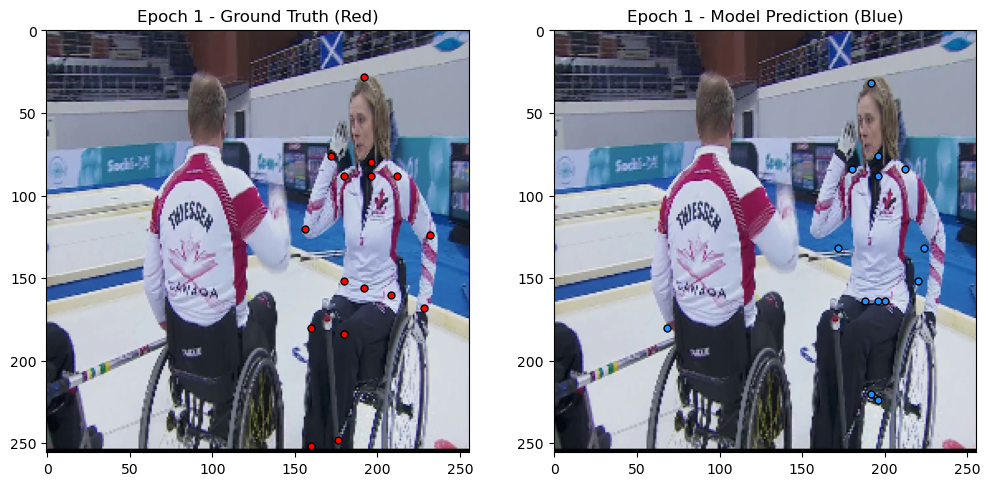

--> [성능 갱신] 최적 모델 저장 완료: best_simplebaseline_model.pth

[Epoch 2/5] Train Loss: 0.002234 | Val Loss: 0.002217


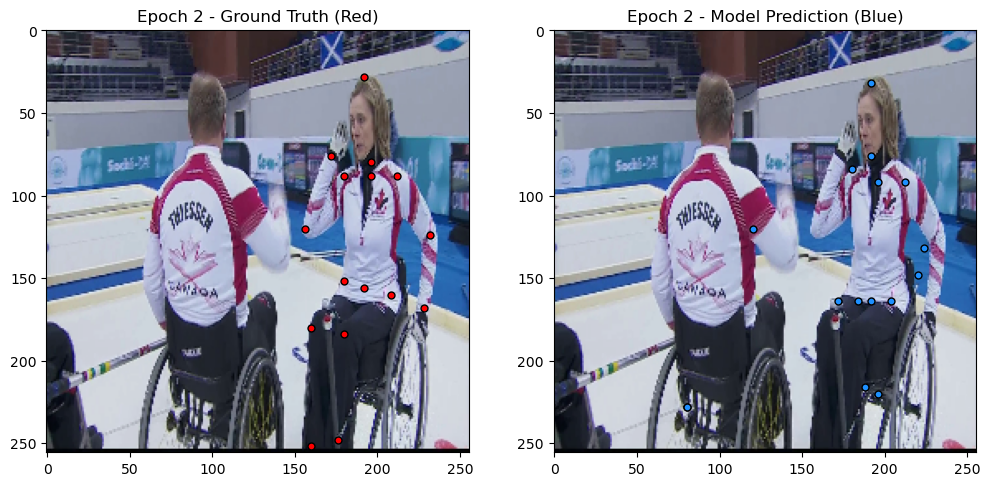

--> [성능 갱신] 최적 모델 저장 완료: best_simplebaseline_model.pth

[Epoch 3/5] Train Loss: 0.002111 | Val Loss: 0.002104


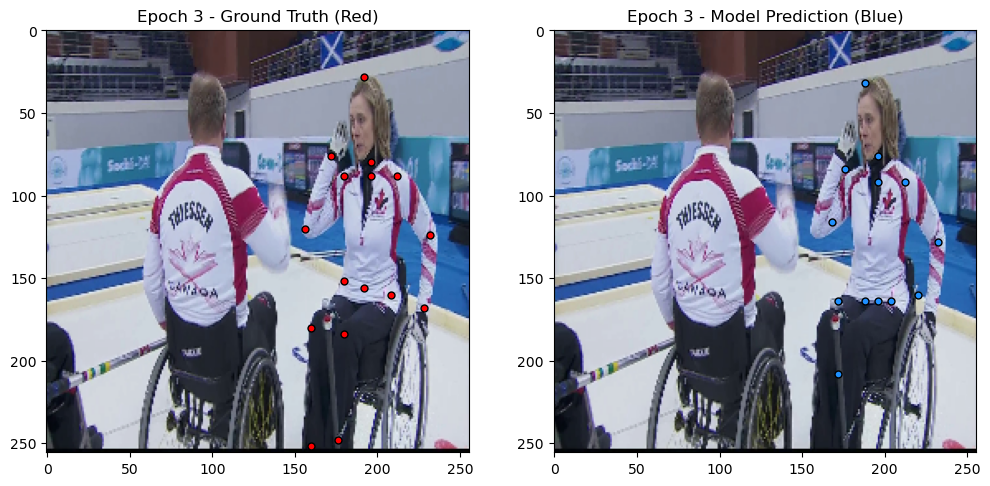

--> [성능 갱신] 최적 모델 저장 완료: best_simplebaseline_model.pth

[Epoch 4/5] Train Loss: 0.002018 | Val Loss: 0.002062


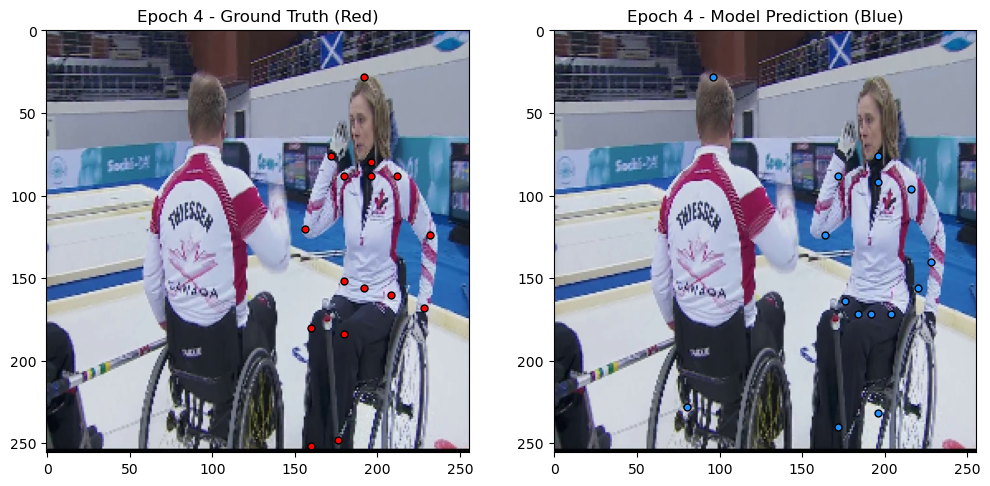

--> [성능 갱신] 최적 모델 저장 완료: best_simplebaseline_model.pth

[Epoch 5/5] Train Loss: 0.001947 | Val Loss: 0.002036


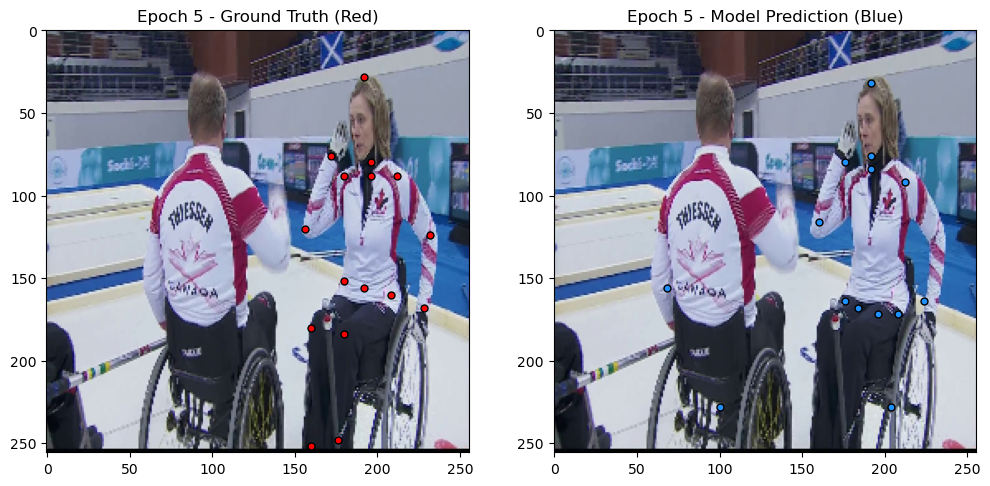

--> [성능 갱신] 최적 모델 저장 완료: best_simplebaseline_model.pth


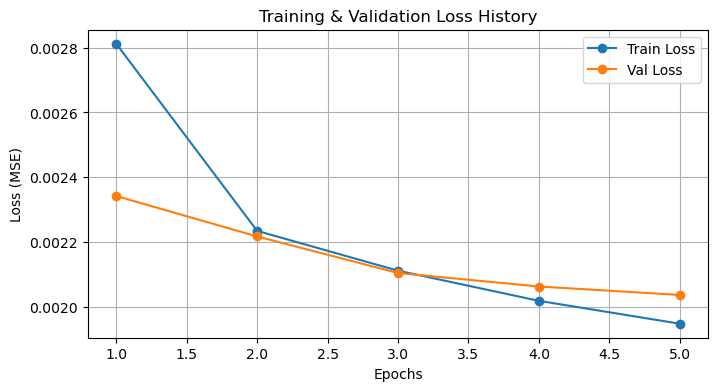

학습 프로세스가 안전하게 완료되었습니다.
CPU times: user 41min 9s, sys: 1min 18s, total: 42min 28s
Wall time: 44min 23s


In [12]:
%%time
import os
PROJECT_PATH = 'work/mpii'
TRAIN_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'train.json')
VAL_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'validation.json')
IMAGE_DIR = os.path.join(PROJECT_PATH, 'images')

# 파라미터 세팅
epochs = 5
batch_size = 4
num_heatmap = 16
learning_rate = 0.0007

# 학습 진행 및 에폭별 실시간 중간 결과 + 최종 Loss 그래프 확인
best_model_file = train(epochs, learning_rate, num_heatmap, batch_size, TRAIN_JSON, VAL_JSON, IMAGE_DIR)

# Step 4 : Pose Estimation 결과 시각화 (정성적 비교)
학습 진행 경과 (loss 감소 현황)

가급적 두 모델 모두 최소 3epoch 이상, (5epoch 이상 권장)을 학습하기 바랍니다.

평가 및 비교 장치: cuda
[경고] Model A 가중치 파일을 찾을 수 없습니다: best_simplebaseline_model.pth
[경고] Model B 가중치 파일을 찾을 수 없습니다: best_comparison_model.pth


/tmp/ipykernel_200/3341349036.py:97: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_200/3341349036.py:97: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


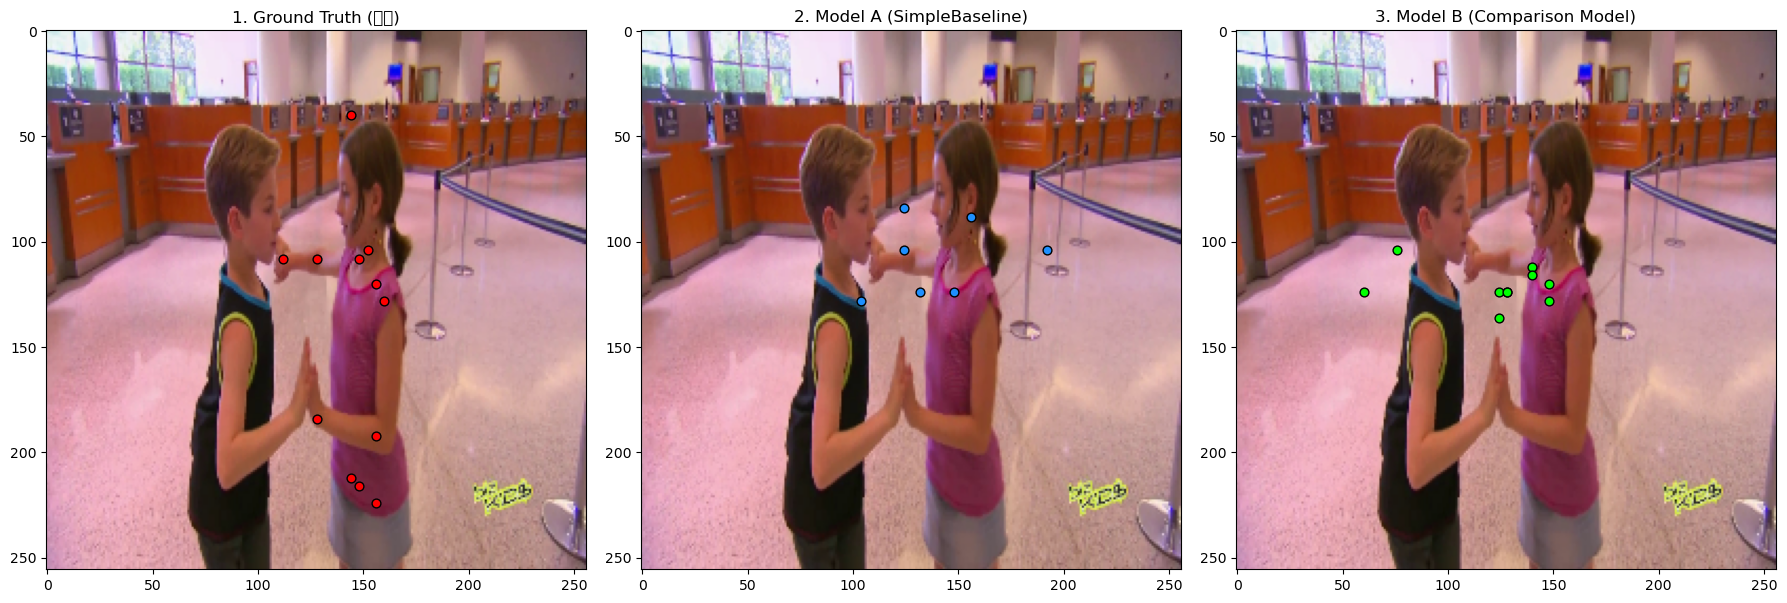

In [14]:
# ==========================================
# Step 4 : Pose Estimation 결과 시각화 (정성적/정량적 비교)
# ==========================================
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

def evaluate_and_compare_models(val_json, image_dir, model_a_path, model_b_path, num_heatmap=16):
    """
    두 가중치 파일(Model A, Model B)을 로드하여 
    Loss 추이 그래프와 실제 이미지 예측 결과를 정성적으로 비교합니다.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"평가 및 비교 장치: {device}")
    
    # 1. 데이터셋 및 데이터로더 준비 (Validation 데이터 사용)
    val_dataset = MPIIDataset(val_json, image_dir, num_heatmap=num_heatmap)
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=True) # 무작위 샘플링을 위해 shuffle=True
    
    # 2. 두 모델 선언 및 가중치 로드
    # [Model A] 기존에 구현한 SimpleBaseline 모델
    model_a = SimpleBaseline(num_heatmap=num_heatmap).to(device)
    if os.path.exists(model_a_path):
        model_a.load_state_dict(torch.load(model_a_path, map_location=device))
        print(f"--> Model A 가중치 로드 완료: {model_a_path}")
    else:
        print(f"[경고] Model A 가중치 파일을 찾을 수 없습니다: {model_a_path}")
        
    # [Model B] 비교군 모델 (구조가 같다면 다른 하이퍼파라미터나 에폭으로 학습된 가중치 지정 가능)
    model_b = SimpleBaseline(num_heatmap=num_heatmap).to(device) 
    if os.path.exists(model_b_path):
        model_b.load_state_dict(torch.load(model_b_path, map_location=device))
        print(f"--> Model B 가중치 로드 완료: {model_b_path}")
    else:
        print(f"[경고] Model B 가중치 파일을 찾을 수 없습니다: {model_b_path}")

    # 3. 모델 평가 모드 전환
    model_a.eval()
    model_b.eval()
    
    # 4. 비교 시각화를 위한 샘플 데이터 추출 (1장)
    iterator = iter(val_loader)
    images, heatmaps = next(iterator)
    
    images = images.to(device)
    
    with torch.no_grad():
        outputs_a = model_a(images)
        outputs_b = model_b(images)
        
    # 5. 이미지 역정규화 변환 (시각화용)
    img_tensor = images[0].cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = np.clip((img_tensor * std + mean) * 255, 0, 255).astype(np.uint8)
    
    gt_heatmap = heatmaps[0].cpu().numpy()
    pred_a_heatmap = outputs_a[0].cpu().numpy()
    pred_b_heatmap = outputs_b[0].cpu().numpy()
    
    # 6. 정성적 비교 시각화 (Ground Truth vs Model A vs Model B)
    plt.figure(figsize=(18, 6))
    
    # [좌측] 정답 관절 위치 (Ground Truth)
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("1. Ground Truth (정답)")
    for i in range(num_heatmap):
        hm = gt_heatmap[i]
        if hm.max() > 0.1:
            y, x = np.unravel_index(np.argmax(hm), hm.shape)
            plt.scatter(x * 4, y * 4, c='red', s=40, edgecolors='black', label='GT' if i==0 else "")
            
    # [중앙] Model A 예측 결과
    plt.subplot(1, 3, 2)
    plt.imshow(img)
    plt.title("2. Model A (SimpleBaseline)")
    for i in range(num_heatmap):
        hm = pred_a_heatmap[i]
        if hm.max() > 0.05:
            y, x = np.unravel_index(np.argmax(hm), hm.shape)
            plt.scatter(x * 4, y * 4, c='dodgerblue', s=40, edgecolors='black')
            
    # [우측] Model B 예측 결과
    plt.subplot(1, 3, 3)
    plt.imshow(img)
    plt.title("3. Model B (Comparison Model)")
    for i in range(num_heatmap):
        hm = pred_b_heatmap[i]
        if hm.max() > 0.05:
            y, x = np.unravel_index(np.argmax(hm), hm.shape)
            plt.scatter(x * 4, y * 4, c='lime', s=40, edgecolors='black')
            
    plt.tight_layout()
    plt.show()

# --- 실험 환경 설정 및 비교 실행 ---
# 가중치 파일 이름 정의 (각각 학습 후 생성된 파일명을 입력해주세요)
MODEL_A_FILE = 'best_simplebaseline_model.pth' # 예: 5에폭 학습 모델
MODEL_B_FILE = 'best_comparison_model.pth'     # 예: 다른 환경 또는 초기 모델

TRAIN_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'train.json')
VAL_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'validation.json')
IMAGE_DIR = os.path.join(PROJECT_PATH, 'images')

# 함수 호출하여 2개 모델 정성적 결과 출력
evaluate_and_compare_models(VAL_JSON, IMAGE_DIR, MODEL_A_FILE, MODEL_B_FILE, num_heatmap=16)

# 이후 발전 
Pose Estimation(자세 추정) 분야는 컴퓨터 비전에서 가장 역동적으로 발전해 온 영역 중 하나입니다. 초기 전통적인 머신러닝 방식에서 벗어나 딥러닝이 도입된 이후, 모델들은 "정확도(Accuracy), 속도(Efficiency), 그리고 복잡한 환경(가림 현상, 다인식 등)에서의 강인함"을 중심으로 진화해 왔습니다.

딥러닝 기반 Pose Estimation의 핵심 발전 흐름을 패러다임 전환과 주요 모델별로 나누어 정리해 드립니다.

---

## 1. 딥러닝의 시작과 CNN 기반 좌표 회귀 (Early Era)

초기 딥러닝 모델들은 이미지에서 관절(Keypoint)의 $(x, y)$ 좌표를 직접 예측(Regression)하는 방식을 사용했습니다.

* **DeepPose (2014):** * **핵심:** Pose Estimation에 처음으로 CNN을 도입한 기념비적인 모델입니다.
* **특징:** 전체 이미지를 CNN에 입력하고, Fully Connected Layer를 통해 관절의 2D 좌표를 직접 출력(Direct Regression)했습니다.
* **한계:** 이미지 공간의 기하학적 특징(Context)을 충분히 활용하지 못해 초기 예측의 정확도가 낮았고, 이를 보완하기 위해 여러 단계의 Cascade(연쇄) 구조를 써야 해서 비효율적이었습니다.



---

## 2. 히트맵(Heatmap) 패러다임으로의 전환

좌표를 직접 맞추는 대신, 특정 관절이 존재할 확률 지도를 그리는 **히트맵(Heatmap) 방식**이 도입되면서 정확도가 비약적으로 상승합니다.

* **Tompson et al. (2014) & Convolutional Pose Machines (CPM, 2016):**
* **핵심:** 이미지 각 픽셀이 특정 관절(예: 오른쪽 손목)일 확률을 나타내는 히트맵을 학습 목표로 삼았습니다. Spatial Context(주변 관절과의 위치 관계)를 컨볼루션 연산으로 자연스럽게 학습할 수 있게 되었습니다.


* **Stacked Hourglass Networks (2016):**
* **핵심:** 엔지니어링 적으로 히트맵 방식의 정점을 찍은 모델입니다.
* **특징:** 이미지를 축소(Pooling)했다가 다시 확대(Upsampling)하는 구조가 모래시계(Hourglass)를 닮았습니다. 이 과정을 여러 번 쌓아(Stacked) 올림으로써, 이미지 전체를 보는 전역적 맥락(Global Context)과 관절 주변의 지역적 특징(Local Feature)을 모두 포착해 냈습니다. 가림(Occlusion) 현상이 있는 관절도 주변 관절 위치를 바탕으로 유추할 수 있게 되었습니다.



---

## 3. Multi-Person(다인원) Pose Estimation의 분화

한 이미지에 여러 사람이 등장할 때, 이를 어떻게 처리할 것인가에 따라 두 가지 핵심 흐름으로 갈라졌습니다.

### Top-Down (하향식) 방식: "사람 먼저 찾고, 관절 찾기"

사람 검출기(Object Detector)로 사람을 먼저 잘라낸 뒤, 잘라낸 영역 안에서 1인용 Pose Estimation을 수행합니다. **정확도가 매우 높지만, 사람이 많아질수록 연산량이 비례해서 증가**합니다.

* **Mask R-CNN (2017):** * Faster R-CNN을 확장하여 객체 검출과 동시에 각 사람 박스 내부에서 Keypoint 히트맵을 바이너리 마스크 형태로 예측했습니다. RoIAlign 기술을 통해 좌표가 뭉개지는 것을 방지했습니다.
* **SimpleBaselines (2018):**
* "구조가 복잡해야만 성능이 잘 나오는가?"라는 질문에서 출발해, ResNet 뒤에 몇 개의 Deconvolution 레이어만 붙인 극도로 단순한 구조로도 당시 최고 수준(SOTA)의 성능을 내며 효율적인 탑다운의 기준을 제시했습니다.


* **HRNet (High-Resolution Net, 2019):**
* **핵심:** 기존 모델들이 해상도를 줄였다가 키우는 과정에서 손실되는 정보에 주목했습니다.
* **특징:** 네트워크 전체 과정 동안 **고해상도(High-Resolution) 특징맵을 계속 유지**하면서, 동시에 저해상도 서브 네트워크를 병렬로 연결해 지속적으로 정보를 주고받았습니다(Multi-scale Fusion). 덕분에 아주 정밀한 관절 위치 예측이 가능해져 현재까지도 많은 뼈대(Backbone) 네트워크로 사랑받고 있습니다.



### Bottom-Up (상향식) 방식: "관절 먼저 다 찾고, 주인 찾아주기"

이미지 안의 모든 관절을 한 번에 다 찾은 뒤, 이 관절들이 누구의 것인지 엮어(Grouping/Association) 줍니다. **사람 수와 상관없이 연산 속도가 일정하여 실시간성에 유리**합니다.

* **OpenPose (2017):**
* **핵심:** 바텀업 방식의 대중화를 이끈 모델입니다.
* **특징:** 관절의 위치(Heatmap)뿐만 아니라, 관절과 관절 사이의 방향과 연결 강도를 나타내는 PAF(Part Affinity Fields)라는 벡터 필드를 함께 예측했습니다. 이 PAF를 기하학적으로 매칭(Greedy Matching)하여 수많은 관절 중에서 한 사람의 skeleton을 올바르게 조립해 냈습니다.



---

## 4. End-to-End 및 Transformer 기반의 현대적 발전 (Modern Era)

최근에는 복잡한 후처리(히트맵에서 최대값 찾기, PAF 조립 등)를 제거하고, End-to-End로 학습하거나 Transformer의 Attention 메커니즘을 활용하는 방향으로 진화하고 있습니다.

* **Regression의 부활 (RLE, Integral Regression):**
* 히트맵 방식은 연산량이 많고 해상도 한계(Quantization error)가 있었습니다. 이를 해결하기 위해 소프트맥스 기반으로 좌표를 미분 가능한 형태로 추출하는 Integral Regression이나, 좌표의 불확실성을 확률 분포로 학습하는 **RLE(Residual Log-likelihood Estimation)** 등이 도입되면서, 다시 **가볍고 빠른 '좌표 회귀' 방식이 탑다운 모델의 주류로 합류**하게 되었습니다.


* **PETR / TokenPose / ViTPose (2021~현재):**
* **핵심:** Vision Transformer(ViT)의 도입입니다.
* **특징 (ViTPose):** 대표적인 거대 비전 트랜스포머 기반 모델로, 이미지의 각 패치를 토큰화하여 관절 간의 장거리 종속성(Long-range dependency, 예: 왼손과 오른발의 관계)을 Attention 연산으로 완벽하게 파악합니다. 구조가 매우 단순함에도 불구하고, 압도적인 데이터 표현력 덕분에 현재 주요 데이터셋(COCO 등)에서 최고 수준의 정확도를 갱신하고 있습니다.


* **YOLOv7-Pose / YOLOv8-Pose / YOLOv11-Pose (Real-time Keypoint):**
* **핵심:** 실시간 객체 검출 모델인 YOLO에 Pose Estimation 헤드를 통합한 형태입니다.
* **특징:** 하나의 Single-shot 인프라 내에서 Object Detection과 Keypoint Regression을 동시에 수행합니다. 탑다운의 정확도와 바텀업 수준의 속도를 절묘하게 타협하여, Edge 디바이스(임베디드, 모바일)나 MLOps 파이프라인에서 **실시간(Real-time) 서빙을 할 때 가장 대중적으로 선택**되는 모델입니다.



---

### 요약하자면

| 발전 단계 | 대표 모델 | 핵심 아이디어 | 장점 / 의의 |
| --- | --- | --- | --- |
| **초기 CNN** | DeepPose | CNN을 통한 좌표 $(x,y)$ 직접 회귀 | Pose Estimation에 딥러닝 최초 도입 |
| **히트맵 혁신** | Stacked Hourglass | 픽셀별 확률 지도(Heatmap) 예측, 인코더-디코더 반복 | 맥락 정보 활용으로 정확도 대폭 상승 |
| **다인원 (하향식)** | HRNet | 고해상도 특징맵을 끝까지 유지하며 병렬 학습 | 정밀한 관절 검출, 최고의 정확도 뼈대 확립 |
| **다인원 (상향식)** | OpenPose | PAF(방향 벡터)를 활용한 관절 매칭 | 사람 수와 무관한 빠른 속도 (실시간성) |
| **트랜스포머 기반** | ViTPose | ViT Backbone + Attention 메커니즘 | 거대 모델 기반의 압도적인 성능 및 일반화 |
| **원샷 실시간** | YOLO-Pose 계열 | Detection과 Keypoint 예측을 하나의 네트워크로 통합 | 극대화된 효율성, 프로덕션 환경 최적화 |

혹시 이 중에서 특정 모델의 아키텍처나 Loss 함수, 혹은 현업/프로젝트 적용 관점에서 더 궁금한 부분이 있으신가요?

# 현업 사용

현업(Industrial & Production environments)에서는 모델의 '논문 기준 정확도(mAP)'보다 '비용 대비 성능(ROI), 인프라 제약, 데이터 파이프라인의 안정성'을 최우선으로 고려합니다.

현업의 도메인별 요구사항에 따라 모델을 선택하고 가공하는 실제 엔지니어링 패턴을 몇 가지로 나누어 설명해 드리겠습니다.

---

## 1. 실시간성 및 Edge 디바이스 서빙 패턴

공장 가동선(제조업), 모바일 앱, 혹은 GPU가 없거나 빈약한 Embedded 디바이스 환경입니다. 연산 비용을 아끼고 레이턴시(Latency)를 최소화하는 것이 핵심입니다.

* **주요 선택 모델:** **YOLO-Pose 계열(YOLOv8-Pose, YOLOv11-Pose)**, RTMPose, MediaPipe
* **실무 적용 방식:**
* **End-to-End 경량화:** Detection과 Keypoint를 하나의 백본에서 뽑아내는 YOLO-Pose를 선택해 엔지니어링 파이프라인을 단순화합니다.
* **최적화 가공:** PyTorch로 학습된 모델을 그대로 서빙하는 경우는 거의 없습니다. 하드웨어 타겟에 맞춰 **TensorRT(NVIDIA GPU), OpenVINO(Intel CPU), ONNX** 형태로 변환(Quantization: FP32 $\rightarrow$ FP16/INT8)하여 FPS를 극대화합니다.
* **예시:** 홈트레이닝 앱에서 사용자의 스쿼트 자세를 실시간 피드백할 때, 서버 비용을 아끼기 위해 온디바이스(On-device)용 MediaPipe나 경량화된 YOLO-Pose를 활용합니다.



---

## 2. 고정밀 분석 및 서버 기반 배치(Batch) 처리 패턴

의료 영상 분석, 스포츠 과학(선수 동작 분석), 혹은 방송 콘텐츠 아카이빙처럼 **속도보다는 한 프레임 한 프레임의 정확도가 절대적인** 환경입니다.

* **주요 선택 모델:** **Top-Down 구조 (HRNet, ViTPose)** + 고성능 Object Detector (YOLOv11 등)
* **실무 적용 방식:**
* **2-Stage 파이프라인 구축:** 먼저 최신 YOLO나 전용 Detection 모델로 사람의 bounding box를 정밀하게 따낸 뒤, 잘라낸 이미지를 HRNet이나 ViTPose에 입력합니다.
* **Triton Inference Server 활용:** 모델이 무겁기 때문에 동시 요청을 효율적으로 처리하기 위해 NVIDIA Triton 같은 전문 추론 서버를 도입합니다. Dynamic Batching을 설정해 여러 장의 이미지를 묶어 큐(Queue) 단위로 처리함으로써 GPU 유틸라이제이션(Utilization)을 극대화합니다.
* **예시:** 골프 스윙 분석 서비스에서 프로 선수의 관절 각도를 정밀하게 측정하여 리포트를 제공할 때 이 조합을 사용합니다.



---

## 3. Top-Down과 Bottom-Up의 현실적인 타협

CCTV 기반의 보안, 리테일 매장 분석(행동 인식), 관제 시스템처럼 **화면에 잡히는 사람의 수가 유동적이고 가림(Occlusion) 현상이 심한** 환경입니다.

* **실무에서의 딜레마와 해결책:**
* 원래 사람 수가 많으면 OpenPose 같은 Bottom-Up이 정석처럼 여겨졌으나, OpenPose는 후처리(PAF 매칭) 연산이 CPU/GPU를 많이 잡아먹어 배포 시 병목이 생기기 쉽습니다.
* 그래서 실제 현업에서는 **"고속 Object Detector(YOLO) + 가벼운 Top-Down(SimpleBaselines 또는 경량 HRNet)"** 조합을 더 선호하는 경향이 있습니다. Detector가 사람을 빠르게 솎아내고, 빈 박스는 스킵하는 방식으로 전체 파이프라인의 속도를 제어합니다.



---

## 4. Keypoint '이후'의 비즈니스 로직 연계 (가장 중요)

현업에서 Pose Estimation 모델의 출력값($(x, y)$ 좌표 배열)은 그 자체로 서비스가 되지 않습니다. 이 데이터를 기반으로 '비즈니스 로직'을 얹는 단계가 진짜 엔지니어링의 시작입니다.

* **Rule-based 기하학 알고리즘:** * 특정 관절들 사이의 벡터 각도(Angle)를 계산하여 자세가 올바른지 판별합니다. (예: 엉덩이-무릎-발목 관절의 각도가 $90^{\circ}$ 이하로 내려갔는가?)
* **시계열 데이터 처리 (Tracking & Action Recognition):**
* 프레임 단위의 좌표를 시간 순으로 묶어(Sequential Data), 사람이 '넘어지는 행동(Fall Detection)'이나 '물건을 훔치는 행동'을 감지합니다.
* 이를 위해 Pose 모델 뒤에 **LSTM, GRU, 혹은 가벼운 ST-GCN(Spatio-Temporal Graph Convolutional Network)** 같은 행동 인식 모델을 파이프라인으로 연결(Chaining)합니다.


* **Kalman Filter / Smooth Filter 적용:**
* 영상의 노이즈나 일시적인 가림 현상 때문에 관절 위치가 파르르 떨리는 징크스(Jittering)가 발생합니다. 서비스 퀄리티를 위해 이동평균(Moving Average)이나 칼만 필터 같은 **Post-processing 필터링**을 필수적으로 얹어 좌표를 부드럽게 보정합니다.



---

### 현업 엔지니어의 체크리스트 요약

현업에서 Pose Estimation 프로젝트를 설계할 때는 기술 스택을 정하기 전 아래 흐름을 먼저 정의합니다.

1. **타겟 환경:** 클라우드 서버 인프라(Triton + 고성능 GPU)인가, 로컬 엣지(Embedded/PC) 환경인가?
2. **카메라 뷰:** 고정뷰(CCTV)인가, 유동뷰(모바일 카메라)인가? (가림 현상 및 해상도 수준 정의)
3. **데이터 특성:** 실시간(Real-time, >30 FPS)이 필수인가, 배치성 후처리(Post-processing) 분석인가?
4. **후속 태스크:** 단순 위치 파악인가, 관절 각도 계산인가, 연속된 행동(Action) 인식인가?

현재 구상 중이시거나 진행하려는 프로젝트의 인프라 환경(GPU 여부, 서빙 방식)이나 도메인을 알려주시면, 그에 맞는 구체적인 아키텍처나 파이프라인 구성(예: Triton 이나 디바이스 최적화 팁)을 더 자세히 짚어드릴 수 있습니다. 어떤 환경을 고민 중이신가요?